In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv("Multiple Linear Regression-Economics Dataset.csv")

In [4]:
df

,Unnamed: 0,Year,Month,Interest_rate,Unemployment_rate,Index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         24 non-null     int64  
 1   Year               24 non-null     int64  
 2   Month              24 non-null     int64  
 3   Interest_rate      24 non-null     float64
 4   Unemployment_rate  24 non-null     float64
 5   Index_price        24 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 KB


In [6]:
df.shape

(24, 6)

In [7]:
df.drop(columns=["Unnamed: 0","Year","Month"],axis=1,inplace=True)

In [8]:
df.isnull().sum()

Interest_rate        0
Unemployment_rate    0
Index_price          0
dtype: int64

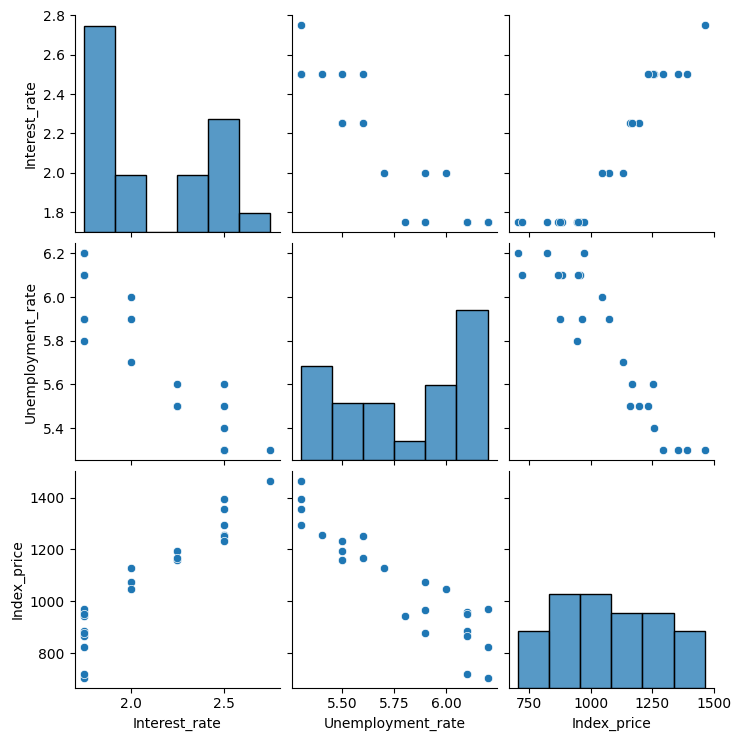

In [18]:
#visulisation
import seaborn as sns
sns.pairplot(df)

In [19]:
df.corr()

,Interest_rate,Unemployment_rate,Index_price
Interest_rate,1.000000,-0.925814,0.935793
Unemployment_rate,-0.925814,1.000000,-0.922338
Index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

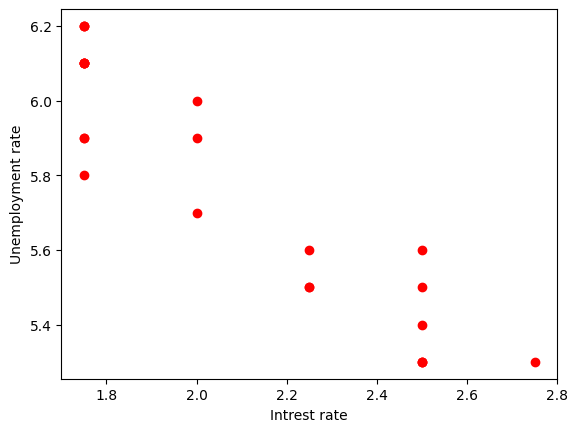

In [20]:
# Visualiza the datapoints more closely

plt.scatter(df['Interest_rate'], df['Unemployment_rate'], color='r')
plt.xlabel("Intrest rate")
plt.ylabel("Unemployment rate")

In [21]:
# x=df[['Interest_rate','Unemployment_rate']]
# y=['Index_price']
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [22]:
x.head()

,Interest_rate,Unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [23]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: Index_price, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

<Axes: xlabel='Interest_rate', ylabel='Index_price'>

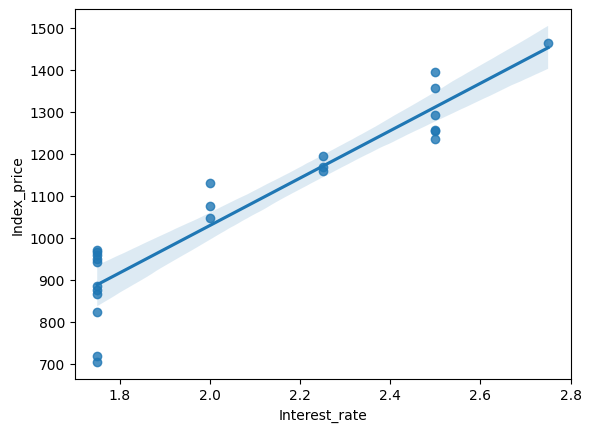

In [26]:
sns.regplot(x=df['Interest_rate'],y=df['Index_price'])

<Axes: xlabel='Interest_rate', ylabel='Unemployment_rate'>

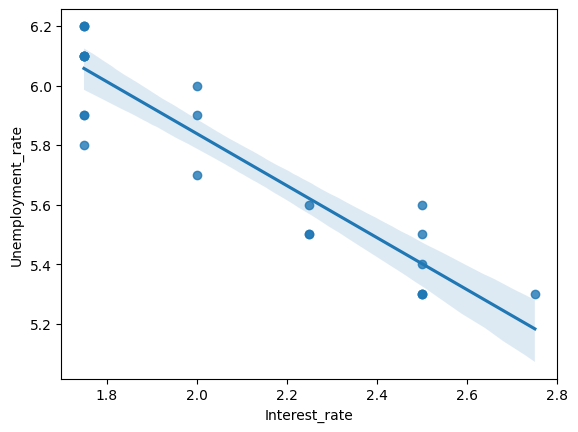

In [27]:
sns.regplot(x=df['Interest_rate'],y=df['Unemployment_rate'])


<Axes: xlabel='Index_price', ylabel='Unemployment_rate'>

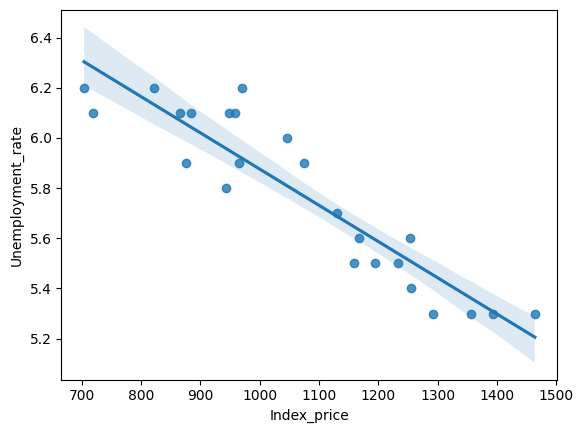

In [28]:
sns.regplot(x=df['Index_price'], y=df['Unemployment_rate'])

In [51]:
#Standardization
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)   # fit + transform on train
x_test = scaler.transform(x_test)         # only transform on test

In [53]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [54]:
x_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
regression=LinearRegression()

In [57]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
print("Coefficient or slope :",regression.coef_)
print("Intercept : ",regression.intercept_)

Coefficient or slope : [  88.27275507 -116.25716066]
Intercept :  1053.4444444444443


In [59]:
# Prediction for test data

y_pred=regression.predict(x_test)

In [60]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [61]:
#Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [62]:
mse=mean_squared_error(y_test,y_pred)  #squares the number of error
mae=mean_absolute_error(y_test,y_pred) #finds the avg of the y_test & y_train data
rmse=np.sqrt(mse) 
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [63]:
from sklearn.metrics import r2_score

In [64]:
score = r2_score(y_test,y_pred) #it should be more that 0.7 which will be best fit 
print(score)  

0.8278978091457145


In [65]:
# Display adjusted R-squared
# Multiple parameters more than 1 than input features 
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.7131630152428576

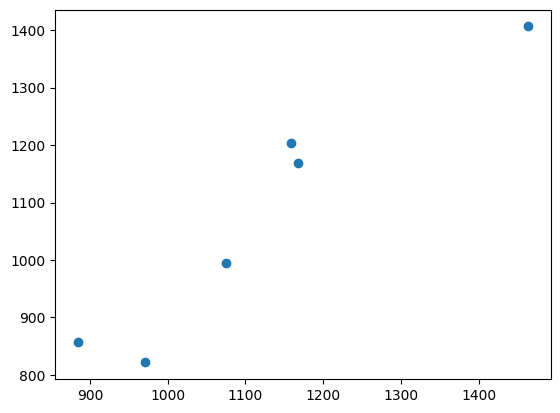

In [66]:
plt.scatter(y_test, y_pred)

In [67]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: Index_price, dtype: float64


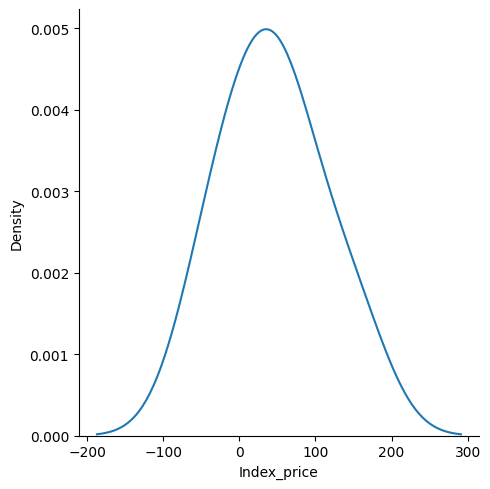

In [68]:
# Plot this residuals
sns.displot(residuals, kind='kde')

In [69]:
## OLS Linear Regression

import statsmodels.api as sm

In [70]:
model = sm.OLS(y_train, x_train).fit()

In [71]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            Index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                       0.754
Time:                        23:09:18   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [72]:
## Prediction for new data
regression.predict(scaler.transform([[2.50, 5.3]]))

C:\Users\patuy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1341.42873089])

In [73]:
df

,Interest_rate,Unemployment_rate,Index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167
